# Vol 24 — Crypto Perpetuals, Liquidation & AMMs

**問い:** funding、margin waterfall、oracle、AMM LVRを同じcash-flow ledgerで追えるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

linear/inverse/quanto、index/mark/last、funding cap、marginとbankruptcy、insurance→ADL→socialized lossを一つのledgerで保存する。CPMM/concentrated liquidityのLVRとfee compensationを別指標にする。cascadeはsynthetic fixtureである。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'stress_paths.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 24
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=24 digest=e65fe57fcc5bb0b9 arrays=61


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

auction_socialized_loss: 6.443163968193039
cashflow_conservation_error: 7.105427357601002e-15
contract_long_short_sign_error: 0.0
contract_zero_move_error: 0.0
dynamic_fee_compensation: 24.658350911738395
dynamic_fee_gross_lvr_reduction: 0.0
ending_adl_notional: 3.0
ending_insurance_fund: 0.0
ending_socialized_loss: 6.443163968193039
ending_uncovered_loss: 0.0
forced_sale_socialized_loss: 8.22316396819304
funding_absolute_cap: 0.005
funding_interval_hours: 8.0
insurance_identity_error: 0.0
oracle_dislocated_count: 1
oracle_stale_count: 5
solvency_identity_error: 0.0
solvent: True
synthetic_cascade: True


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS perpetual_contract_identities 3 linear/inverse/quanto long-short and zero-move identities
PASS cashflow_conservation 7.105427357601002e-15 < 1e-12
PASS funding_cap_interval 8.0 positive interval, absolute cap, and conserved transfers
PASS solvency_identity 0.0 < 1e-12
PASS insurance_identity 0.0 < 1e-12
PASS stress_waterfall 6.443163968193039 ADL/social loss tracked with zero uncovered loss
PASS liquidation_method_waterfalls 2 forced sale and auction conserve their stress waterfalls
PASS amm_identity 0.0 < 1e-12
PASS amm_lvr_fee_variants 7.105427357601002e-15 CPMM identity plus finite fixed/dynamic/concentrated LVR
PASS oracle_staleness_dislocation 5/1 both explicit flags agree with their counts


## index/mark/last price states

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

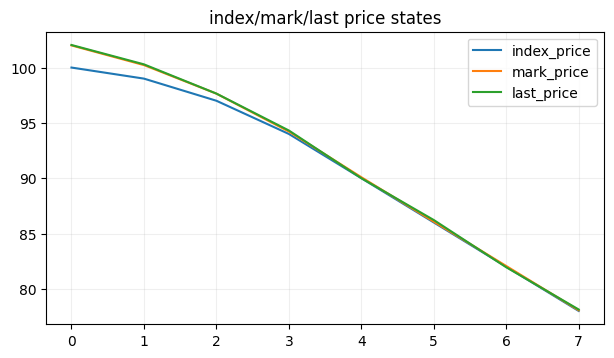

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("index/mark/last price states")
ax.plot(data["step"], data["index_price"], label="index_price")
ax.plot(data["step"], data["mark_price"], label="mark_price")
ax.plot(data["step"], data["last_price"], label="last_price")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## insurance fund and ADL waterfall

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

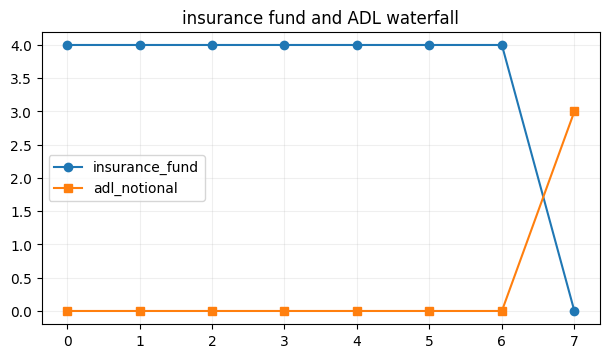

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("insurance fund and ADL waterfall")
ax.plot(data["step"], data["insurance_fund"], marker="o", label="insurance_fund")
ax.plot(data["step"], data["adl_notional"], marker="s", label="adl_notional")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## stress-path solvency identity

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

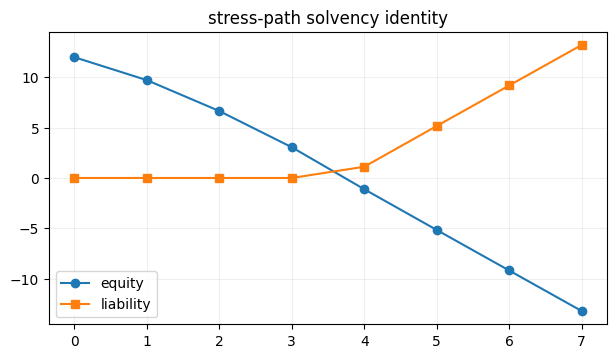

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("stress-path solvency identity")
ax.plot(data["step"], data["equity"], marker="o", label="equity")
ax.plot(data["step"], data["liability"], marker="s", label="liability")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## AMM LVR and fee compensation

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

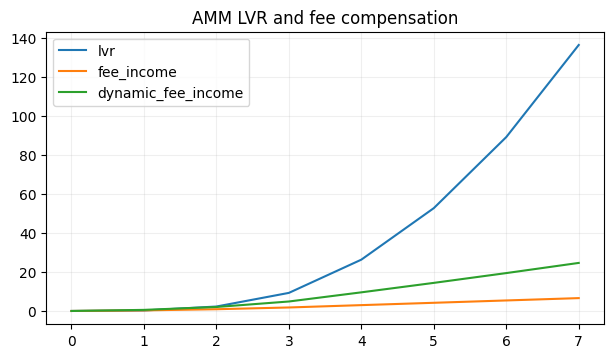

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("AMM LVR and fee compensation")
ax.plot(data["step"], data["lvr"], label="lvr")
ax.plot(data["step"], data["fee_income"], label="fee_income")
ax.plot(data["step"], data["dynamic_fee_income"], label="dynamic_fee_income")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Perpetual swap funding literature; Milionis et al. (2022), Loss-Versus-Rebalancing.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。